# Machine Learning for Geoscience
### CU Boulder — Python for Geologists

You are an exploration geologist working a gold district in Arizona. A regional stream sediment survey has returned **57 element concentrations** at hundreds of sample sites across the study area. Your job: find patterns in that data that point toward buried mineralisation.

Human eyes can compare two elements at a time. ML can compare all 57 simultaneously — and do it across the whole landscape at once.

In this session you will run three techniques on that dataset:

| Method | Type | What it does here |
|--------|------|-------------------|
| **PCA** | Unsupervised | Compresses 57 elements into a handful of summary scores |
| **K-means** | Unsupervised | Groups samples by geochemical similarity — no labels needed |
| **Random Forest** | Supervised | Learns from known deposits to score every sample location |

These are not exploration-specific tools. As you work through each section you will see sidebars showing where the exact same technique appears in stratigraphy, petroleum geology, environmental science, and petrology. The dataset is exploration-flavoured; the skills transfer directly.

**How this notebook works:** Most cells are already written. Cells marked `# --- YOUR TURN ---` ask you to change one or two numbers, re-run the cell, and interpret the output. You cannot break anything — fallback defaults are built in.

---
## Section 0: Setup
*Run these cells once at the start. They install packages (Colab only), import libraries, and point the notebook at the data folder.*

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd

import helpers as h

# ── Data paths ─────────────────────────────────────────────────────────────
GEOCHEM_PATH = Path("data/vector/geochem.geojson")
LITHOLOGY_PATH = Path("data/vector/lithology.geojson")
OCCURRENCES_PATH = Path("data/vector/mineral occurrences.geojson")
SPECTRAL_DIR = Path("data/raster/spectral")
GEOPHYSICS_DIR = Path("data/raster/geophys")
PROSPECTIVITY_TIF_CANDIDATES = [
    Path("data/raster/ML/stacked_result.tif"),
    Path("data/raster/ML/stacked_result.tif"),
    Path("data/raster/outputs/ML/stacked_result.tif"),
]
PROSPECTIVITY_TIF = next(
    (p for p in PROSPECTIVITY_TIF_CANDIDATES if p.exists()),
    next(iter(Path(".").glob("**/stacked_result.tif")), None),
)

print("Paths configured.")
if PROSPECTIVITY_TIF is None:
    print(
        "Prospectivity raster not found in the repo. Run the full ML pipeline or update PROSPECTIVITY_TIF."
    )
else:
    print(f"Prospectivity raster: {PROSPECTIVITY_TIF}")

Paths configured.
Prospectivity raster not found in the repo. Run the full ML pipeline or update PROSPECTIVITY_TIF.


---
## Section 2: Look at the Data
*Before fitting any model, always look at what you have.*

In [2]:
# SECTION 2: DATA LOOK | ~5 min | Target: min 10

# Load the datasets
geochem_gdf = h.ensure_xy(gpd.read_file(GEOCHEM_PATH))
vector_gdf = gpd.read_file(LITHOLOGY_PATH)
targets_gdf = gpd.read_file(OCCURRENCES_PATH)

# Feature columns = numeric, not coordinates
EXCLUDE = {"X", "Y", "id", "coord_x", "coord_y", "elevation_m", "OBJECTID", "FID"}
feature_cols = [
    c
    for c in geochem_gdf.select_dtypes(include=[np.number]).columns
    if c not in EXCLUDE
]

print(f"Geochem samples   : {len(geochem_gdf)}")
print(f"Lithology units   : {len(vector_gdf)}")
print(f"Known occurrences : {len(targets_gdf)}")
print(f"\nGeochem element columns ({len(feature_cols)} total):")
print(feature_cols[:10], "...")

Geochem samples   : 1243
Lithology units   : 463
Known occurrences : 52

Geochem element columns (57 total):
['SiO2_percent_xrf', 'Al2O3_percent_xrf', 'TFe2O3_percent_xrf', 'K2O_percent_xrf', 'MgO_percent_icp', 'CaO_percent_icp', 'Na2O_percent_icp', 'TC_percent_irs', 'LOI_percent_gr', 'Re_ppb_icp'] ...


In [3]:
# Quick table view — what does each row look like?
geochem_gdf[feature_cols[:8]].head()

,SiO2_percent_xrf,Al2O3_percent_xrf,TFe2O3_percent_xrf,K2O_percent_xrf,MgO_percent_icp,CaO_percent_icp,Na2O_percent_icp,TC_percent_irs
0,75.64,9.92,0.79,5.03,0.31,2.57,1.69,0.51
1,66.76,10.39,2.17,3.30,0.91,4.42,2.51,0.74
2,62.73,12.65,2.35,3.30,0.99,5.35,3.53,0.80
3,59.50,13.04,3.01,2.84,1.14,7.57,3.39,1.17
4,57.60,13.82,3.27,2.12,1.31,8.12,3.71,1.07


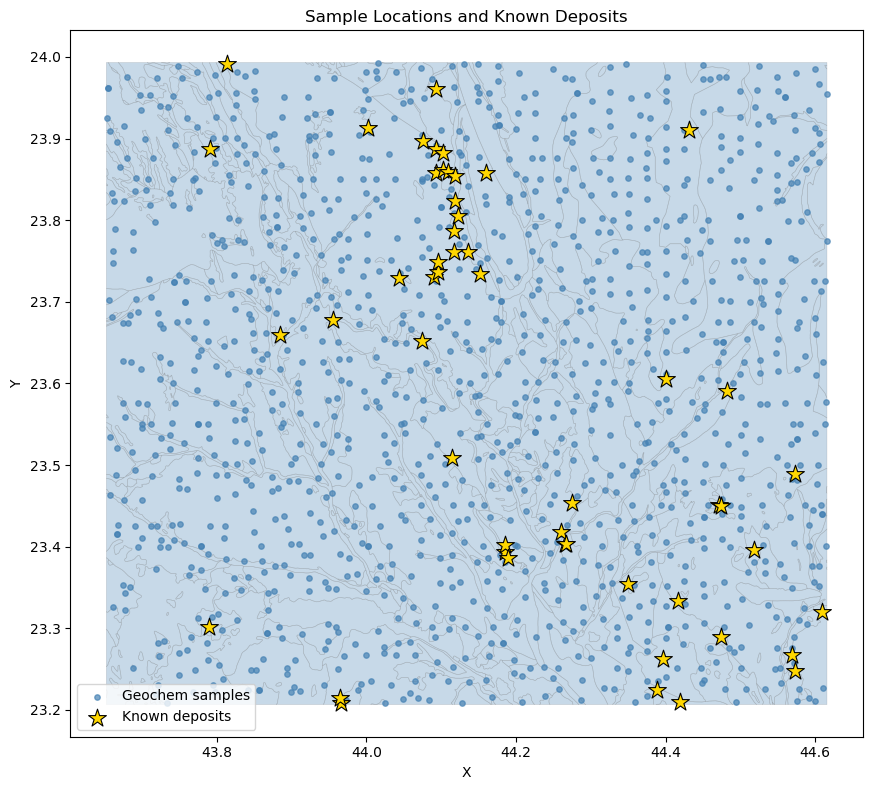

In [4]:
# Map: sample locations on lithology, with known deposit locations marked
fig, ax = plt.subplots(figsize=(10, 8))

h.plot_vector(
    vector_gdf,
    ax=ax,
    title="Sample Locations and Known Deposits",
    alpha=0.3,
    edgecolor="grey",
    linewidth=0.4,
)

geochem_gdf.plot(
    ax=ax, color="steelblue", markersize=15, alpha=0.7, label="Geochem samples"
)

tgt_proj = (
    targets_gdf.to_crs(geochem_gdf.crs)
    if targets_gdf.crs != geochem_gdf.crs
    else targets_gdf
)
tgt_proj.plot(
    ax=ax,
    marker="*",
    color="gold",
    markersize=180,
    edgecolor="black",
    linewidth=0.8,
    label="Known deposits",
    zorder=5,
)

ax.legend()
plt.tight_layout()
plt.show()

**What you're looking at:** Blue dots are geochemical sample sites. Gold stars are known mineral occurrences. Background polygons are mapped lithology units.

**Interpret this map:**
1. Are sample sites evenly distributed, or do some areas have denser coverage?
2. Do any occurrences cluster in a particular lithology?
3. What does the spatial distribution of samples tell you about potential data bias?

> **Instructor note:** Spatial sampling bias is a real problem in any field application — the same issue appears in facies classification from wells (wells are drilled where you expect something, not at random).

---
## Section 3: PCA — Compressing 57 Elements Into Something Useful

### What is PCA?

In our Arizona dataset, many elements move together. Cu, Mo, and Au co-vary in porphyry systems. As, Sb, and Hg co-vary along epithermal pathways. Fe and Mn track weathering. PCA finds those co-varying groups and replaces them with new summary variables called **principal components**.

Instead of 57 maps — one per element — you get 5 summary maps that together capture most of the geochemical information. PC1 captures the dominant pattern in the dataset; PC2 captures the next largest independent pattern; and so on.

**What is variance explained?** Each PC explains some fraction of the total spread in the data. If PC1 explains 40% of variance, then 40% of all geochemical variation across the study area is described by that single new axis.

---

> **The same idea in other fields:**
> - *Stratigraphy:* PCA of drill core geochemistry (30+ elements) collapses the data into 2–3 scores that reveal chemostratigraphic packages — useful when the visual lithology is monotonous shale
> - *Petrology:* Major element PCA of volcanic rocks automatically recovers the classic TAS and AFM discrimination diagrams from the data, without manually choosing axes
> - *Environmental:* Multi-element groundwater PCA separates natural background from contamination plumes, and can distinguish multiple industrial sources by their loading signatures
> - *Petroleum:* PCA of log suites (GR, density, sonic, resistivity) creates composite curves that reduce noise and correlate better across wells than any single log

---

> **Instructor note:** The coin-sorting analogy works well: sorting by size first, then by colour, is analogous to PCA finding the axes of maximum variation in order of importance.

In [5]:
# SECTION 3: PCA | ~15 min | Target: min 10

# --- YOUR TURN ---
# Should we log-transform the geochemistry before PCA?
# Geochemical data is log-normally distributed — a few very high outliers dominate
# the variance if you don't transform first.
# 'log1p' applies log(x+1) to compress those outliers.
# Try 'none' and compare the variance plot — does PC1 dominate more without the transform?
#
TRANSFORM = "log1p"  # Options: 'log1p'  or  'none'
SCALE = True  # Options: True (standardise each element) or False

# Safety fallback — don't edit below this line
try:
    assert TRANSFORM in ("log1p", "none"), "TRANSFORM must be 'log1p' or 'none'"
    assert isinstance(SCALE, bool), "SCALE must be True or False"
except AssertionError as e:
    print(f"Invalid setting: {e}  → using defaults")
    TRANSFORM, SCALE = "log1p", True

pca_inputs = h.prepare_pca_inputs(
    geochem_gdf,
    feature_cols,
    transform=TRANSFORM,
    scale_features=SCALE,
)
X_scaled = pca_inputs["X_scaled"]
pca_cols = pca_inputs["pca_cols"]
print(f"Transform: {TRANSFORM} | Scale: {SCALE}")
print(f"Feature matrix shape: {X_scaled.shape}")

Original dimensions: 57
Transform: log1p | Scale: True
Feature matrix shape: (1243, 57)


In [6]:
# Fit PCA — keep all components so we can see the full variance curve
pca, X_pca = h.fit_pca_model(X_scaled)
print(f"Input dimensions : {X_scaled.shape[1]} elements")
print(f"Output dimensions: {X_pca.shape[1]} principal components")
print(f"Shape of PCA scores: {X_pca.shape}  (one row per sample)")

Input dimensions : 57 elements
Output dimensions: 57 principal components
Shape of PCA scores: (1243, 57)  (one row per sample)


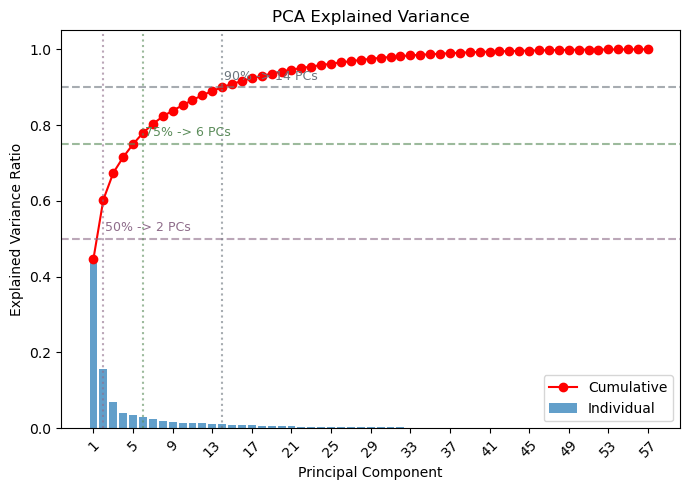

In [7]:
# Variance explained plot — how many PCs do we actually need?
fig, ax = h.plot_pca_variance(pca)
plt.show()

**What you're looking at:** Each bar is one principal component. The red line shows cumulative variance. The dashed lines mark 50%, 75%, and 90% thresholds.

**Interpret this plot:**
1. PC1 explains ____% of variance.
2. How many PCs do you need to reach 75% of total variance? _____
3. Where is the "elbow" — the point where adding another PC stops helping much? _____
4. If you used `TRANSFORM = 'none'`, how does PC1% change? What does that tell you about raw geochemical data distributions?

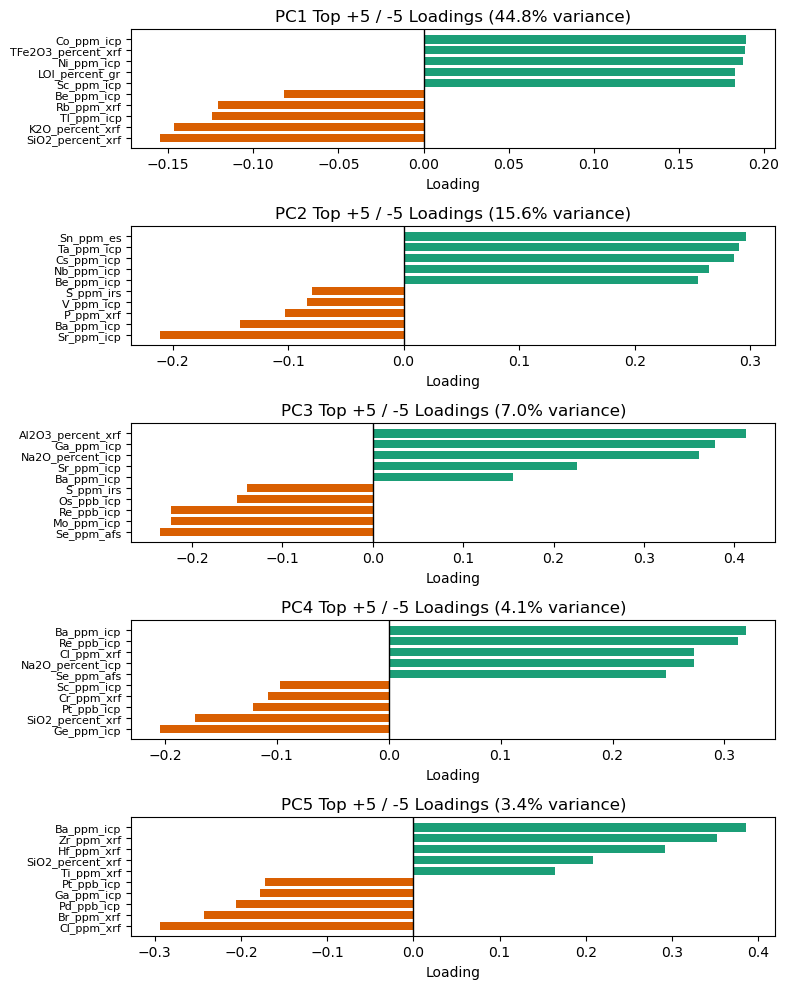

In [8]:
# --- YOUR TURN ---
# How many PCA components should we plot loadings for?
# A "loading" tells you which variables drive each PC.
# Positive loading = variable increases with PC score.
# Negative loading = variable decreases with PC score.
# Try 2, 3, or 5 — do later PCs still make geological sense?
#
N_LOAD_COMPONENTS = 5  # Try: 2, 3, or 5

# Safety fallback
try:
    N_LOAD_COMPONENTS = int(N_LOAD_COMPONENTS)
    assert (
        1 <= N_LOAD_COMPONENTS <= pca.n_components_
    ), f"Must be between 1 and {pca.n_components_}"
except Exception as e:
    print(f"Invalid input: {e}  → using N_LOAD_COMPONENTS = 3")
    N_LOAD_COMPONENTS = 3

fig, axes = h.plot_pca_loadings(pca, pca_cols, n_components=N_LOAD_COMPONENTS)
plt.show()

**What you're looking at:** Each subplot shows one PC. Green bars load positively; orange bars load negatively. Bar length shows how strongly that element contributes.

**Interpret these loadings:**
1. What element has the strongest positive loading on PC1? _____
2. What element has the strongest negative loading on PC1? _____
3. Elements like As, Sb, Hg, and Tl are classic hydrothermal pathfinders. Which PC are they associated with?
4. What geological process might explain the pattern you see in PC2?

> **Instructor note:** If time allows, ask students to hypothesise what a PC loading pattern would look like in their own field — e.g., what would PC1 look like for a well log PCA in a carbonate succession?

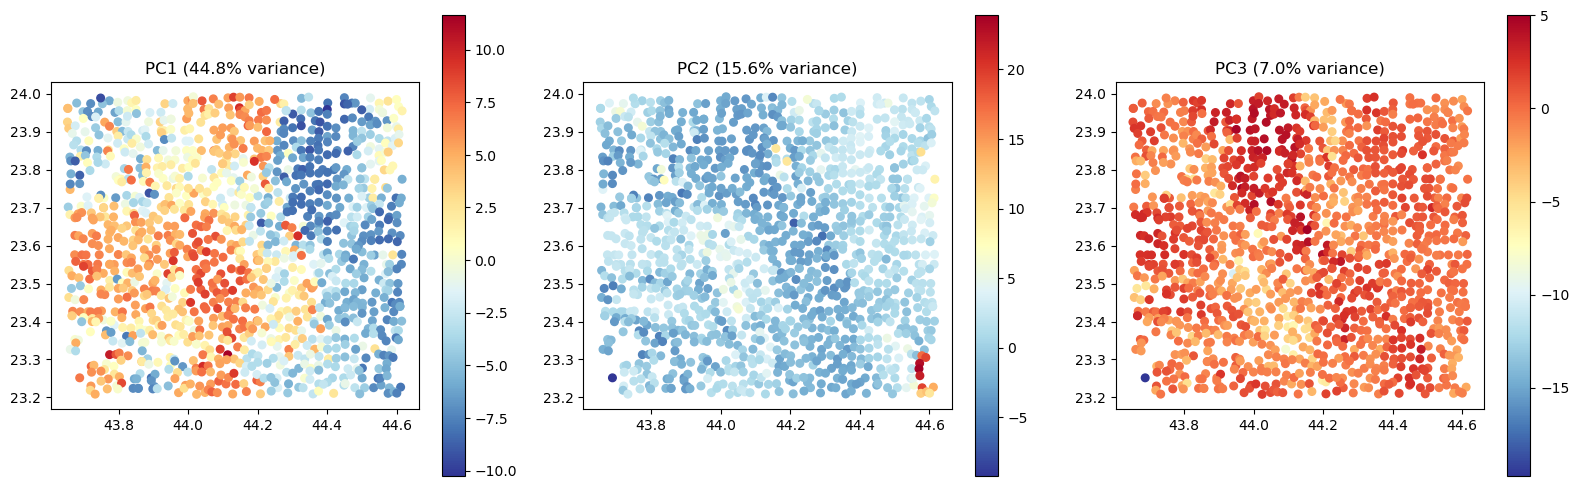

In [9]:
# Map the first 3 PCA scores in geographic space
fig, axes = h.plot_spatial_pca_components(geochem_gdf, X_pca, pca, n_components=3)
plt.show()

**What you're looking at:** Each map shows the PC score at each sample location. Warm = high; cool = low. Compare these to the lithology map from Section 2.

**Interpret these maps:**
1. Does PC1 vary smoothly across the study area, or does it show sharp boundaries?
2. Do PC score boundaries correspond to lithology contacts? What would that mean?
3. Do any known deposit locations appear in high or low PC score zones?
4. If this were a chemostratigraphy dataset (core samples down a section instead of points across a map), what would each map represent?

---
## Section 4: K-means — Finding Geochemical Populations

### What is K-means?

PCA compressed our 57 elements into summary scores. K-means takes the next step: it partitions every sample into one of *k* discrete groups based on similarity across all variables at once.

In an exploration context, those groups might represent distinct geochemical populations — background granites, altered zones, mineralised samples. But we don't tell the algorithm that. It finds the groupings from the data alone, and then we interpret them geologically.

Unlike PCA, K-means gives each sample a **label** (Cluster 0, Cluster 1, ...) that can be plotted directly on a map and compared against lithology, structure, or deposit locations.

**The challenge:** you have to choose *k* before running. We will use two diagnostics to help:
- **Elbow plot:** how much does within-cluster variance decrease as k increases? Look for the bend.
- **Silhouette score:** how cleanly separated are the clusters? Higher is better (max = 1).

---

> **The same idea in other fields:**
> - *Petroleum geology:* K-means on GR, density, and sonic logs classifies every depth interval into electrofacies — widely used when no core is available and the geologist needs discrete units for reservoir modelling
> - *Stratigraphy:* Clustering element ratios down a drill core reveals chemostratigraphic boundaries without relying on visual description, which is inherently subjective
> - *Provenance:* Detrital zircon or heavy mineral chemistry clustered to identify how many source regions contributed to a sedimentary basin, and in what proportions
> - *Environmental:* Groundwater samples clustered to separate pristine aquifer from contaminated zones and mixing end-members — useful before any regulatory sampling decisions

---

> **Instructor note:** There is no single correct k. Two geologists might reasonably choose different values and both be right — the goal is geological interpretability, not metric optimisation.

In [10]:
# SECTION 4: K-MEANS | ~13 min | Target: min 10

# Run diagnostics for k = 2 through 8
K_RANGE = range(2, 9)
print("Running K-means diagnostics for k =", list(K_RANGE), "...")
inertias, silhouettes = h.run_kmeans_diagnostics(X_scaled, K_RANGE)
print("Done.")

Running K-means diagnostics for k = [2, 3, 4, 5, 6, 7, 8] ...
Done.


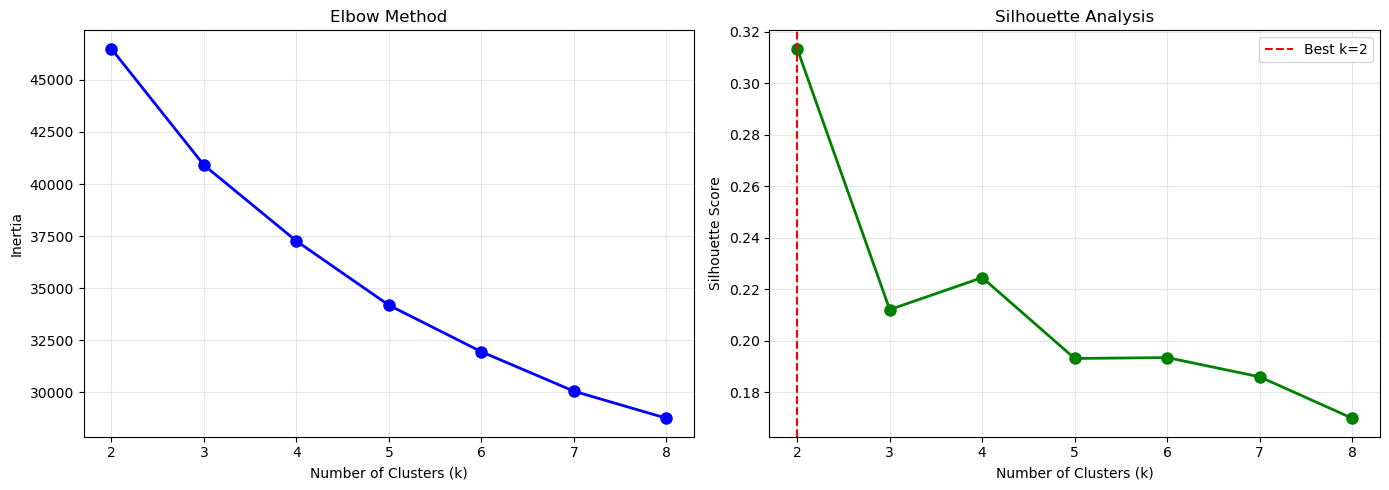

In [11]:
# Elbow and silhouette plots
fig, axes = h.plot_elbow_silhouette(list(K_RANGE), inertias, silhouettes)
plt.show()

**What you're looking at:** Left = elbow plot (lower inertia = tighter clusters). Right = silhouette scores (higher = more distinct clusters; 0.2–0.5 is typical for real geochemical data).

**Interpret these plots:**
1. Where is the elbow in the left plot? _____
2. Which k gives the highest silhouette score? _____
3. Do the two diagnostics agree? If not, which would you trust more, and why?
4. What would k = 2 represent geologically (e.g., in a porphyry system? in a shelf carbonate succession)?

In [12]:
# --- YOUR TURN ---
# Choose the number of clusters based on the plots above.
# The algorithm will suggest an elbow-based value, but you can override it.
# Try at least two different values and compare the maps that follow.
#
MY_K = 3  # Try: 3, 4, or 5

# Safety fallback
try:
    MY_K = int(MY_K)
    assert 2 <= MY_K <= 10, "k must be between 2 and 10"
except Exception as e:
    print(f"Invalid k: {e}  → using k = 4")
    MY_K = 4

chosen_k = h.choose_k(list(K_RANGE), inertias, user_override=MY_K)
cluster_labels = h.run_kmeans_clustering(X_scaled, n_clusters=chosen_k)

print(f"\nCluster label counts:")
unique, counts = np.unique(cluster_labels, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Cluster {u}: {c} samples")

Elbow method suggests k=5
Using user override: k=3

Cluster label counts:
  Cluster 0: 418 samples
  Cluster 1: 472 samples
  Cluster 2: 353 samples


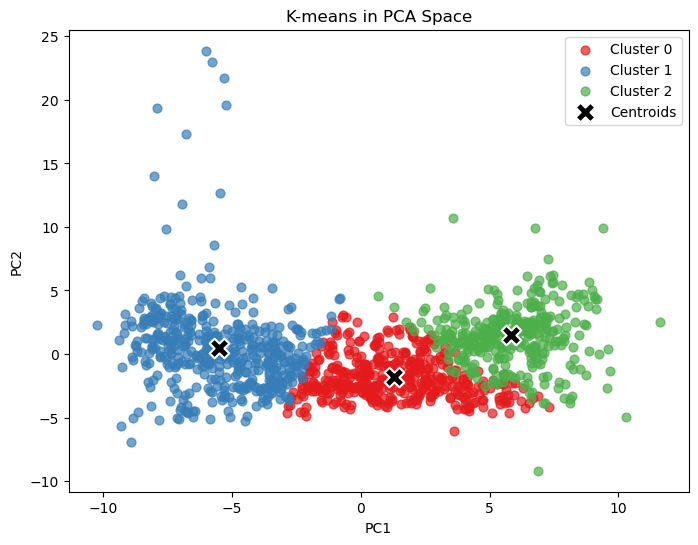

In [13]:
# PCA scatter coloured by cluster — do the groups separate cleanly in PC space?
fig, ax = h.plot_kmeans_pca_scatter(X_pca, cluster_labels)
plt.show()

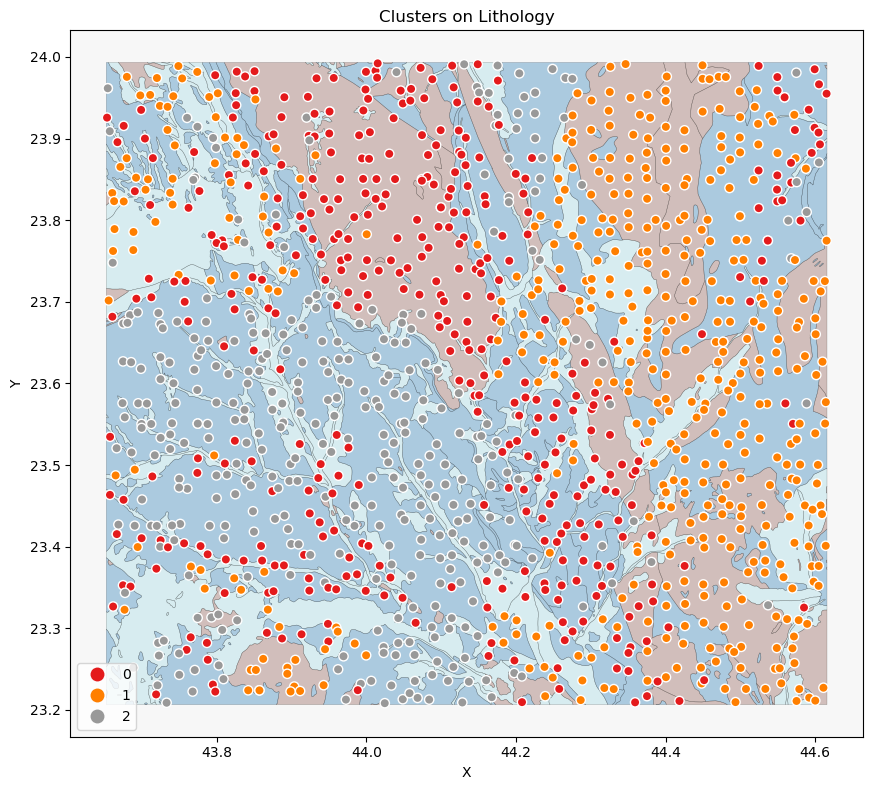

In [14]:
# Geographic overlay — do clusters follow lithology contacts?
fig, ax = h.plot_clusters_on_lithology(vector_gdf, geochem_gdf, cluster_labels)
plt.show()

**What you're looking at:** Clusters overlaid on lithology polygons. If clusters align with lithology contacts, the element patterns are controlled by source rock composition. If they cut across contacts, something else is driving them — possibly hydrothermal alteration, or a transported signal.

**Interpret these maps:**
1. Do any clusters follow lithology contact lines? _____
2. Are any clusters scattered across multiple lithologies? What might that indicate?
3. Are known deposit locations concentrated in one cluster?
4. Try a different MY_K. Do the same groupings persist at different k, or do boundaries shift dramatically?

> **Instructor note:** Clusters that track lithology = lithogeochemistry (source rock control). Clusters that cut contacts = hydrothermal overprinting. Same logic applies to well log electrofacies — do they match the stratigrapher's core description?

---
## Section 5: Supervised ML — Predicting Mineral Prospectivity

### From patterns to predictions

PCA and K-means found structure in the data without any labels. Now we give the algorithm something specific to learn: **known mineral occurrences**.

We label each sample location as:
- **1 (positive)** — within 500 m of a known deposit
- **0 (background)** — everything else

Then we train a **Random Forest**: an ensemble of decision trees, each trained on a random subset of the data. Each tree votes on whether a new sample looks deposit-like. The output is a probability from 0 to 1.

```
Spectral + geophysics  ──►  Feature matrix  ──►  Random Forest  ──►  Probability score
(sampled at points)        (standardised)       (100 trees)         (0 = background, 1 = deposit-like)
```

**Features for this section:** We extract only raster predictors at each sample location: spectral remote sensing layers and geophysics layers. Geochem assays and lithology polygons are not used as model inputs here.
To reduce spatial autocorrelation leakage, train/test evaluation uses a checkerboard split in projected space instead of a random split.

> **Instructor note:** The training targets remain the porphyry deposits, but the predictor stack in this notebook is restricted to spectral + geophysics rasters.

In [ ]:
# SECTION 5: SUPERVISED ML | ~20 min | Target: min 10

# --- YOUR TURN ---
# Set all parameters here before running the cells below.

# RADIUS_M: how close must a sample be to a known deposit to count as "positive"?
# Smaller radius = fewer positives, harder problem. Larger = more signal, easier.
RADIUS_M = 5000  # options: 1000 (tight)  |  2000 (moderate)  |  5000 (generous)
# RADIUS_M = 1000
# RADIUS_M = 2000

# N_ESTIMATORS: number of decision trees. More = slower but often more stable.
N_ESTIMATORS = 100  # options: 50 (fast)  |  100 (balanced)  |  200 (thorough)
# N_ESTIMATORS = 50
# N_ESTIMATORS = 200

# MAX_DEPTH: how deep each tree can grow. None = unlimited.
MAX_DEPTH = None  # options: None (full depth)  |  5 (shallow)  |  10 (medium)
# MAX_DEPTH = 5
# MAX_DEPTH = 10

# CHECKER_SIZE_M: spatial checkerboard cell size for train/test split (metres)
CHECKER_SIZE_M = 5000  # options: 2500 | 5000 | 10000

print(
    f"radius={RADIUS_M} m | trees={N_ESTIMATORS} | max_depth={MAX_DEPTH} | checker={CHECKER_SIZE_M} m"
)

radius=5000 m | trees=100 | max_depth=None | checker=5000 m


Raster layers extracted: 13
Positive samples (within 5000m of deposit): 331 | Background: 912
Positive : 331  (26.6%)
Background: 912  (73.4%)
Note: class_weight='balanced' will compensate for imbalance in the model.


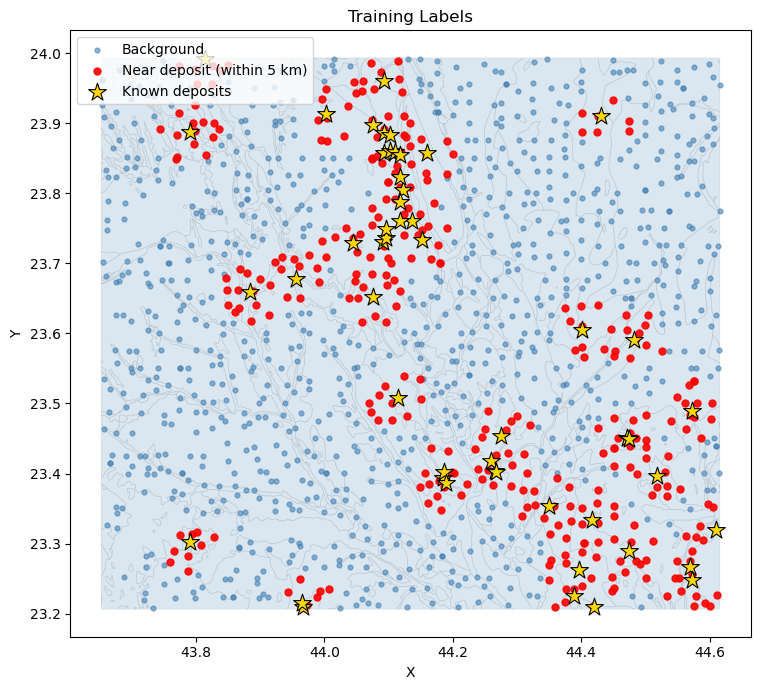

In [ ]:
# ── Step 1: Extract raster predictors and create labels ─────────────────────
X_raw, predictor_names = h.extract_raster_values(
    geochem_gdf, SPECTRAL_DIR, GEOPHYSICS_DIR
)
y = h.prepare_ml_labels(geochem_gdf, targets_gdf, radius_m=RADIUS_M)

n_pos = int(y.sum())
n_neg = len(y) - n_pos
print(f"Positive : {n_pos}  ({100*n_pos/len(y):.1f}%)")
print(f"Background: {n_neg}  ({100*n_neg/len(y):.1f}%)")
print("Note: class_weight='balanced' will compensate for imbalance in the model.")

# Map of training labels
fig, ax = plt.subplots(figsize=(10, 7))
h.plot_vector(vector_gdf, ax=ax, alpha=0.2, edgecolor="grey", linewidth=0.4)
geochem_gdf[y == 0].plot(
    ax=ax, color="steelblue", markersize=12, alpha=0.6, label="Background"
)
geochem_gdf[y == 1].plot(
    ax=ax,
    color="red",
    markersize=25,
    alpha=0.9,
    label=f"Near deposit (within {RADIUS_M//1000} km)",
)
tgt_proj.plot(
    ax=ax,
    marker="*",
    color="gold",
    markersize=180,
    edgecolor="black",
    linewidth=0.8,
    label="Known deposits",
    zorder=5,
)
ax.set_title("Training Labels")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ── Preview: what do the input rasters look like? ─────────────────────────
# Show one example from each category so you can see what the model is reading.
import rasterio
from pyproj import Transformer

layers_to_preview = [
    (
        SPECTRAL_DIR / "idx_clay_hydroxyls.tif",
        "Spectral — Clay Hydroxyls Index",
        "YlOrBr",
    ),
    (GEOPHYSICS_DIR / "AMF_RTP.tif", "Geophysics — Magnetics (RTP)", "RdBu_r"),
]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, (path, title, cmap) in zip(axes, layers_to_preview):
    with rasterio.open(path) as src:
        data = src.read(1).astype(float)
        if src.nodata is not None:
            data[data == src.nodata] = np.nan
        b = src.bounds
        extent = (b.left, b.right, b.bottom, b.top)

        # Reproject sample/deposit coords to raster CRS if needed
        if src.crs and geochem_gdf.crs and src.crs != geochem_gdf.crs:
            t = Transformer.from_crs(geochem_gdf.crs, src.crs, always_xy=True)
            px, py = t.transform(
                geochem_gdf.geometry.x.values, geochem_gdf.geometry.y.values
            )
            tx, ty = t.transform(tgt_proj.geometry.x.values, tgt_proj.geometry.y.values)
        else:
            px, py = geochem_gdf.geometry.x.values, geochem_gdf.geometry.y.values
            tx, ty = tgt_proj.geometry.x.values, tgt_proj.geometry.y.values

    vmax = np.nanpercentile(data, 98)
    vmin = np.nanpercentile(data, 2)
    im = ax.imshow(
        data,
        extent=extent,
        origin="upper",
        aspect="auto",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
    )
    plt.colorbar(im, ax=ax, shrink=0.7, label="Value")

    ax.scatter(
        px[y == 0],
        py[y == 0],
        c="white",
        s=10,
        alpha=0.35,
        linewidths=0,
        zorder=3,
        label="Background",
    )
    ax.scatter(
        px[y == 1],
        py[y == 1],
        c="lime",
        s=30,
        alpha=0.85,
        linewidths=0.4,
        edgecolors="black",
        zorder=4,
        label="Positive",
    )
    ax.scatter(
        tx,
        ty,
        marker="*",
        c="gold",
        s=150,
        edgecolors="black",
        linewidths=0.8,
        zorder=5,
        label="Known deposits",
    )

    ax.set_title(title)
    ax.legend(fontsize=8, loc="lower right")

plt.tight_layout()
plt.show()

**What you're looking at:** Two examples from the 13 raster layers that feed the model. Each pixel is a measurement — the model samples the value at each geochem point location (shown as dots).

- **Left (spectral):** A ratio of specific SWIR wavelengths sensitive to clay minerals that form during hydrothermal alteration.
- **Right (geophysics):** Aeromagnetic field reduced to the magnetic pole — highlights magnetic bodies in the crust.

**Think about it:** Do the green dots (positive samples, near deposits) tend to fall in distinctive zones on either map? That's the signal the Random Forest is learning to detect.

In [20]:
# ── Step 2: Build feature matrix ──────────────────────────────────────────
# Drop rows where any predictor is missing (sample outside raster coverage)
valid = ~np.isnan(X_raw).any(axis=1)
X, y_valid = X_raw[valid], y[valid]
gdf_valid = geochem_gdf.iloc[valid].reset_index(drop=True)

# Standardise so all features contribute equally regardless of value range
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)

print(f"Samples with full raster coverage: {valid.sum()} / {len(valid)}")
print(f"Feature matrix: {X.shape[0]} samples × {X.shape[1]} raster predictors")

Samples with full raster coverage: 1243 / 1243
Feature matrix: 1243 samples × 13 raster predictors


Train: 615 samples (173 positive) | Test: 628 samples (158 positive)


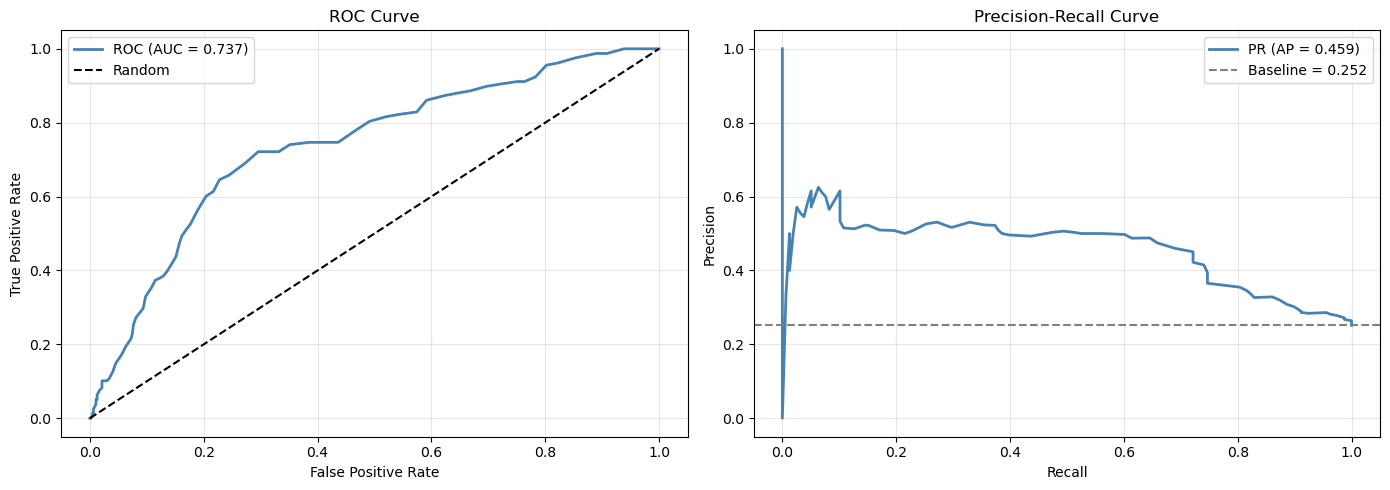

In [21]:
# ── Step 3: Split, train, and evaluate ────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier

split = h.spatial_checkerboard_split(gdf_valid, y=y_valid, cell_size_m=CHECKER_SIZE_M)
X_train, X_test = X[split["train_mask"]], X[split["test_mask"]]
y_train, y_test = y_valid[split["train_mask"]], y_valid[split["test_mask"]]

print(
    f"Train: {len(X_train)} samples ({int(y_train.sum())} positive) | "
    f"Test: {len(X_test)} samples ({int(y_test.sum())} positive)"
)

rf = RandomForestClassifier(
    n_estimators=N_ESTIMATORS,
    max_depth=MAX_DEPTH,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)
rf.fit(X_train, y_train)
y_prob = rf.predict_proba(X_test)[:, 1]

importance_df = pd.DataFrame(
    {
        "feature": predictor_names,
        "importance": rf.feature_importances_,
    }
).sort_values("importance", ascending=False)

# ROC and Precision-Recall curves
fig, axes = h.plot_roc_pr_curves(y_test, y_prob)
plt.show()

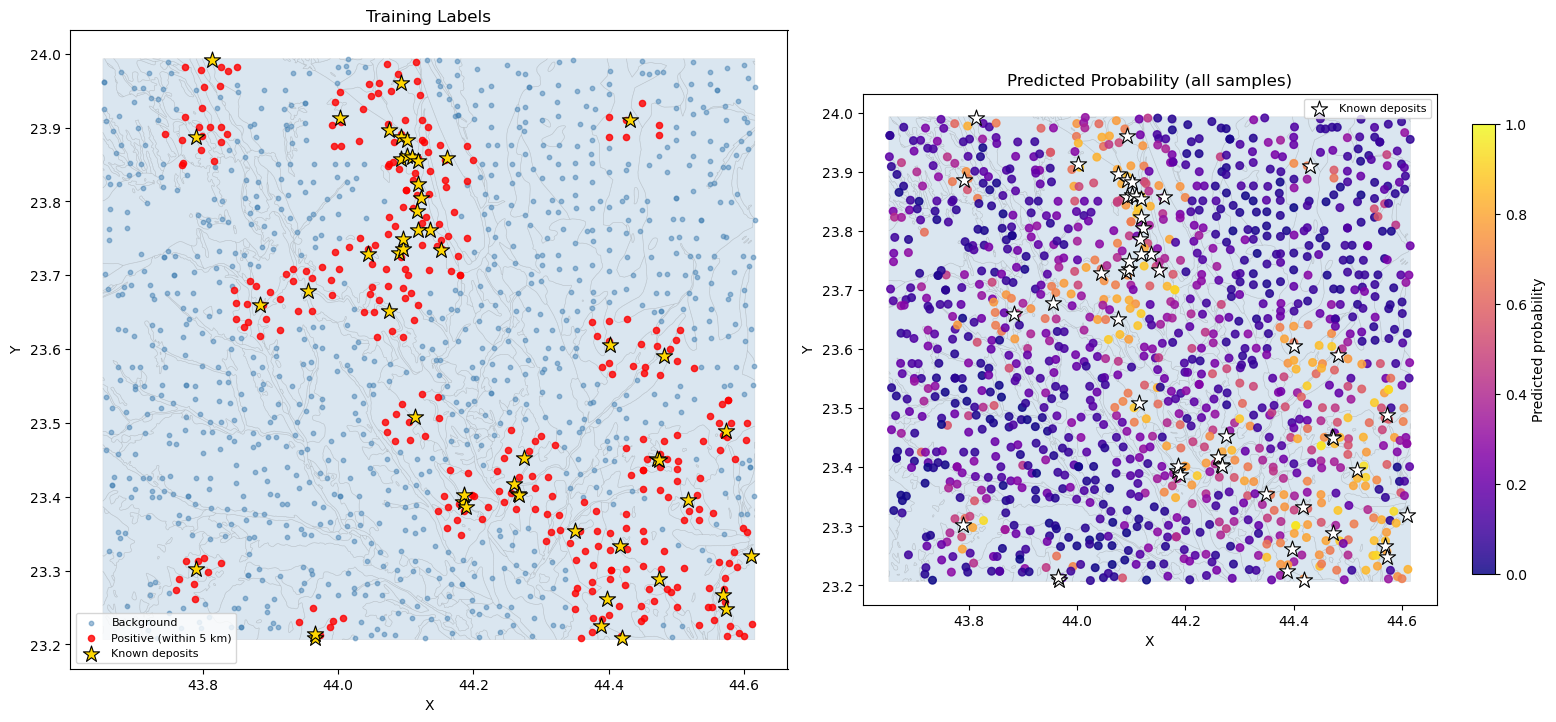

In [ ]:
# ── Predicted probability map ─────────────────────────────────────────────
# Predict on all samples so we can see the full spatial picture,
# not just the test set.
y_prob_all = rf.predict_proba(X)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ── Left: training labels ──────────────────────────────────────────────────
ax = axes[0]
h.plot_vector(vector_gdf, ax=ax, alpha=0.2, edgecolor="grey", linewidth=0.4)
gdf_valid[y_valid == 0].plot(
    ax=ax, color="steelblue", markersize=10, alpha=0.5, label="Background"
)
gdf_valid[y_valid == 1].plot(
    ax=ax,
    color="red",
    markersize=20,
    alpha=0.8,
    label=f"Positive (within {RADIUS_M//1000} km)",
)
tgt_proj.plot(
    ax=ax,
    marker="*",
    color="gold",
    markersize=150,
    edgecolor="black",
    linewidth=0.8,
    label="Known deposits",
    zorder=5,
)
ax.set_title("Training Labels")
ax.legend(fontsize=8)

# ── Right: predicted probability ───────────────────────────────────────────
ax = axes[1]
h.plot_vector(vector_gdf, ax=ax, alpha=0.2, edgecolor="grey", linewidth=0.4)
sc = ax.scatter(
    gdf_valid.geometry.x,
    gdf_valid.geometry.y,
    c=y_prob_all,
    cmap="plasma",
    vmin=0,
    vmax=1,
    s=30,
    alpha=0.85,
    zorder=3,
)
tgt_proj.plot(
    ax=ax,
    marker="*",
    color="white",
    markersize=150,
    edgecolor="black",
    linewidth=0.8,
    label="Known deposits",
    zorder=5,
)
plt.colorbar(sc, ax=ax, label="Predicted probability", shrink=0.7)
ax.set_title("Predicted Probability (all samples)")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

**What you're looking at:** Left = the labels the model was trained on. Right = the model's predicted probability for every sample, coloured from low (dark purple) to high (bright yellow).

**Interpret this map:**
1. Do high-probability zones (yellow) overlap with the gold stars?
2. Are there high-probability areas with no known deposits? Could those be missed deposits, or false alarms?
3. Change `RADIUS_M` and re-run. How does the probability map change when you make the positive zone larger or smaller?
4. Compare the right map to the cluster map from Section 4. Do any K-means clusters align with high-probability zones?

**What you're looking at:** The ROC curve shows the trade-off between catching real deposits (True Positive Rate) and generating false alarms (False Positive Rate). The area under the curve (AUC) is the headline number.

**Interpret these curves:**
1. What is the AUC of your model? _____
2. AUC = 0.5 means _____ . AUC = 1.0 means _____.
3. Try `RADIUS_M = 1000` vs `5000`. How does a tighter labeling radius affect AUC? Why?
4. Try `N_ESTIMATORS = 50` vs `200`. Does AUC change meaningfully?

> **Instructor note:** Spectral + geophysics AUC will usually drop relative to a random split, because the checkerboard evaluation is stricter and reduces spatial leakage.

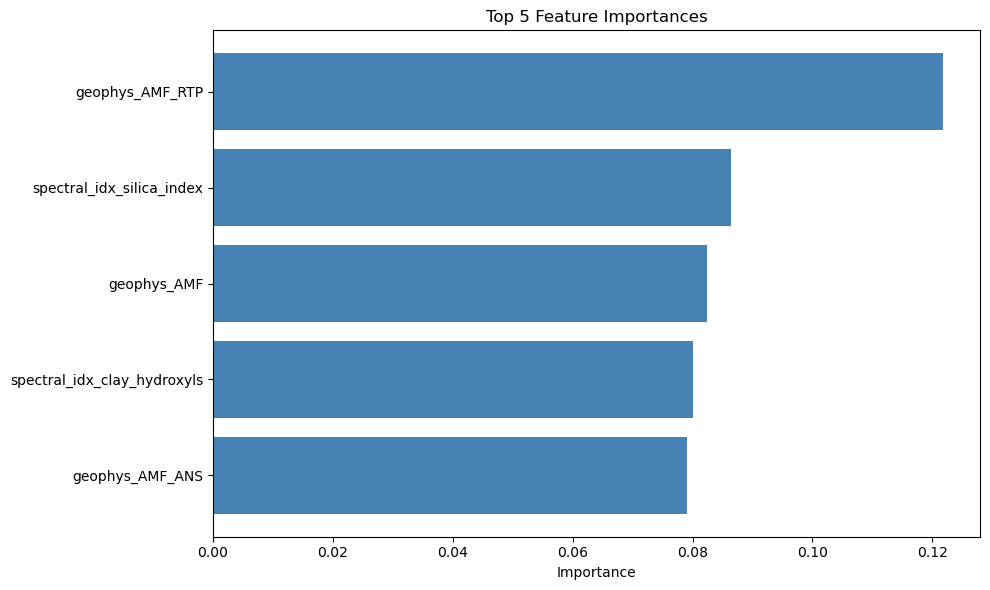

In [19]:
# --- YOUR TURN ---
# How many top predictor layers do you want to display?
TOP_N = 5  # Try: 3, 5, or all (set to len(predictor_names))

fig, ax = h.plot_feature_importance(importance_df, top_n=TOP_N)
plt.show()

**What you're looking at:** Which raster predictor layers drove the model's decisions. Longer bar = more important.

**Interpret this chart:**
1. What is the most important predictor layer? _____
2. Are spectral alteration indices near the top, or are geophysics layers carrying more signal?
3. If you set `MAX_DEPTH = 5`, does the importance ranking change?
4. Try a different `RADIUS_M`. Do the same layers stay on top?

---
## Section 6: Wrap-Up

### What you covered today

| Section | Method | Type | What it produced |
|---------|--------|------|------------------|
| 3 | PCA | Unsupervised | Summary geochemical components; element association patterns |
| 4 | K-means | Unsupervised | Discrete geochemical populations mapped against lithology |
| 5 | Random Forest | Supervised | Deposit probability score at each sample location |

### The exploration geologist's toolkit — and everyone else's

You ran all three techniques on an Arizona gold dataset, but none of them know they're doing exploration. Swap the input data and the interpretation changes; the code does not.

| Your data | PCA gives you | K-means gives you | Supervised ML gives you |
|-----------|--------------|-------------------|------------------------|
| Well log suite | Composite curves, noise-reduced | Electrofacies without core | Reservoir quality prediction |
| Core geochemistry | Chemostratigraphic axes | Unit boundaries, objective picks | Lithology prediction at unsampled depths |
| Groundwater chemistry | Source fingerprints | Contamination populations | Risk scores at unmonitored wells |
| Satellite multispectral | Spectral end-members | Land cover / alteration classes | Hazard or resource probability maps |

### How the full exploration pipeline works

The notebook trained on point data — one row per sample location. In production:
- Geochem, spectral, and geophysical rasters are all combined as input features
- A spatial cross-validation scheme prevents the model from memorising deposit locations instead of learning the underlying signal
- Multiple independent model runs are stacked — the final map is a consensus probability
- Uncertainty is quantified alongside the probability score and delivered to the client

The core ML is what you ran today. The complexity is in the data pipeline around it.

### Topics to explore next

- **Anomaly detection** with Isolation Forest — flags unusual samples without any deposit labels
- **Positive-unlabelled learning** — formally handles the fact that "background" ≠ "confirmed absence of deposit"
- **Spatial cross-validation** — why random train/test split over-estimates model performance for spatially correlated data
- **UMAP / t-SNE** — non-linear dimensionality reduction for datasets where PCA misses curved structure